**Handling Missing Data**

The primary goal of this script is to handle missing data in the Parkinson's disease (PPMI) dataset, It carefully examined the level of missingness in each feature and the type (MCAR, MAR, MNAR) and enriched the dataset by using imputation techniques MICE,which addresses the type and level of missingness observed.  It also preprocesses the APOE genotype data.

In [29]:
!pip install statsmodels

In [30]:
import pandas as pd
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

In [31]:
df = pd.read_csv("baseline_df3.csv")

In [32]:
df.head(10)

,PATNO,EVENT_ID_x,NP1RTOT,NP2PTOT,NP3TOT,NP1DDS,NP1APAT,NP2WALK,NP2FREZ,NP3BRADY,...,caudalanteriorcingulate_avg,posteriorcingulate_avg,entorhinal_avg,parahippocampal_avg,insula_avg,supramarginal_avg,APOE,COHORT_DEFINITION,EVENT_ID_y,AGE_AT_VISIT
0,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,656.5,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,BL,69.1
1,3001,BL,0.0,2.0,12.0,0.0,0.0,0.0,0.0,1.0,...,756.5,857.5,510.0,767.5,2550.5,4355.0,E3/E3,Parkinson's Disease,BL,65.1
2,3002,BL,3.0,15.0,17.0,0.0,1.0,1.0,1.0,2.0,...,503.0,948.5,417.0,581.0,2083.5,3015.0,E3/E3,Parkinson's Disease,BL,67.6
3,3003,BL,1.0,6.0,29.0,0.0,0.0,1.0,0.0,2.0,...,394.0,804.0,416.0,659.5,2352.5,3477.5,E3/E4,Parkinson's Disease,BL,56.7
4,3004,BL,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,576.5,1085.5,509.0,697.0,2404.5,4814.0,E2/E3,Healthy Control,BL,59.4
5,3006,BL,1.0,4.0,22.0,0.0,0.0,0.0,0.0,1.0,...,726.0,1116.0,422.0,788.0,2302.5,4149.5,E3/E4,Parkinson's Disease,BL,57.5
6,3007,BL,1.0,6.0,21.0,0.0,0.0,0.0,0.0,1.0,...,661.0,1077.5,554.5,783.0,3173.0,4982.5,E2/E3,Parkinson's Disease,BL,64.5
7,3008,BL,1.0,2.0,10.0,0.0,0.0,0.0,0.0,0.0,...,360.0,907.5,439.5,620.0,2010.5,2896.5,E3/E3,Healthy Control,BL,81.9
8,3009,BL,2.0,3.0,6.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E3/E4,Healthy Control,BL,83.7
9,3010,BL,2.0,11.0,19.0,0.0,1.0,1.0,0.0,1.0,...,834.0,1399.0,496.0,790.5,2817.0,5187.0,E3/E3,Parkinson's Disease,BL,47.0


In [33]:
df.shape

(2014, 38)

In [34]:
!pip install missingno

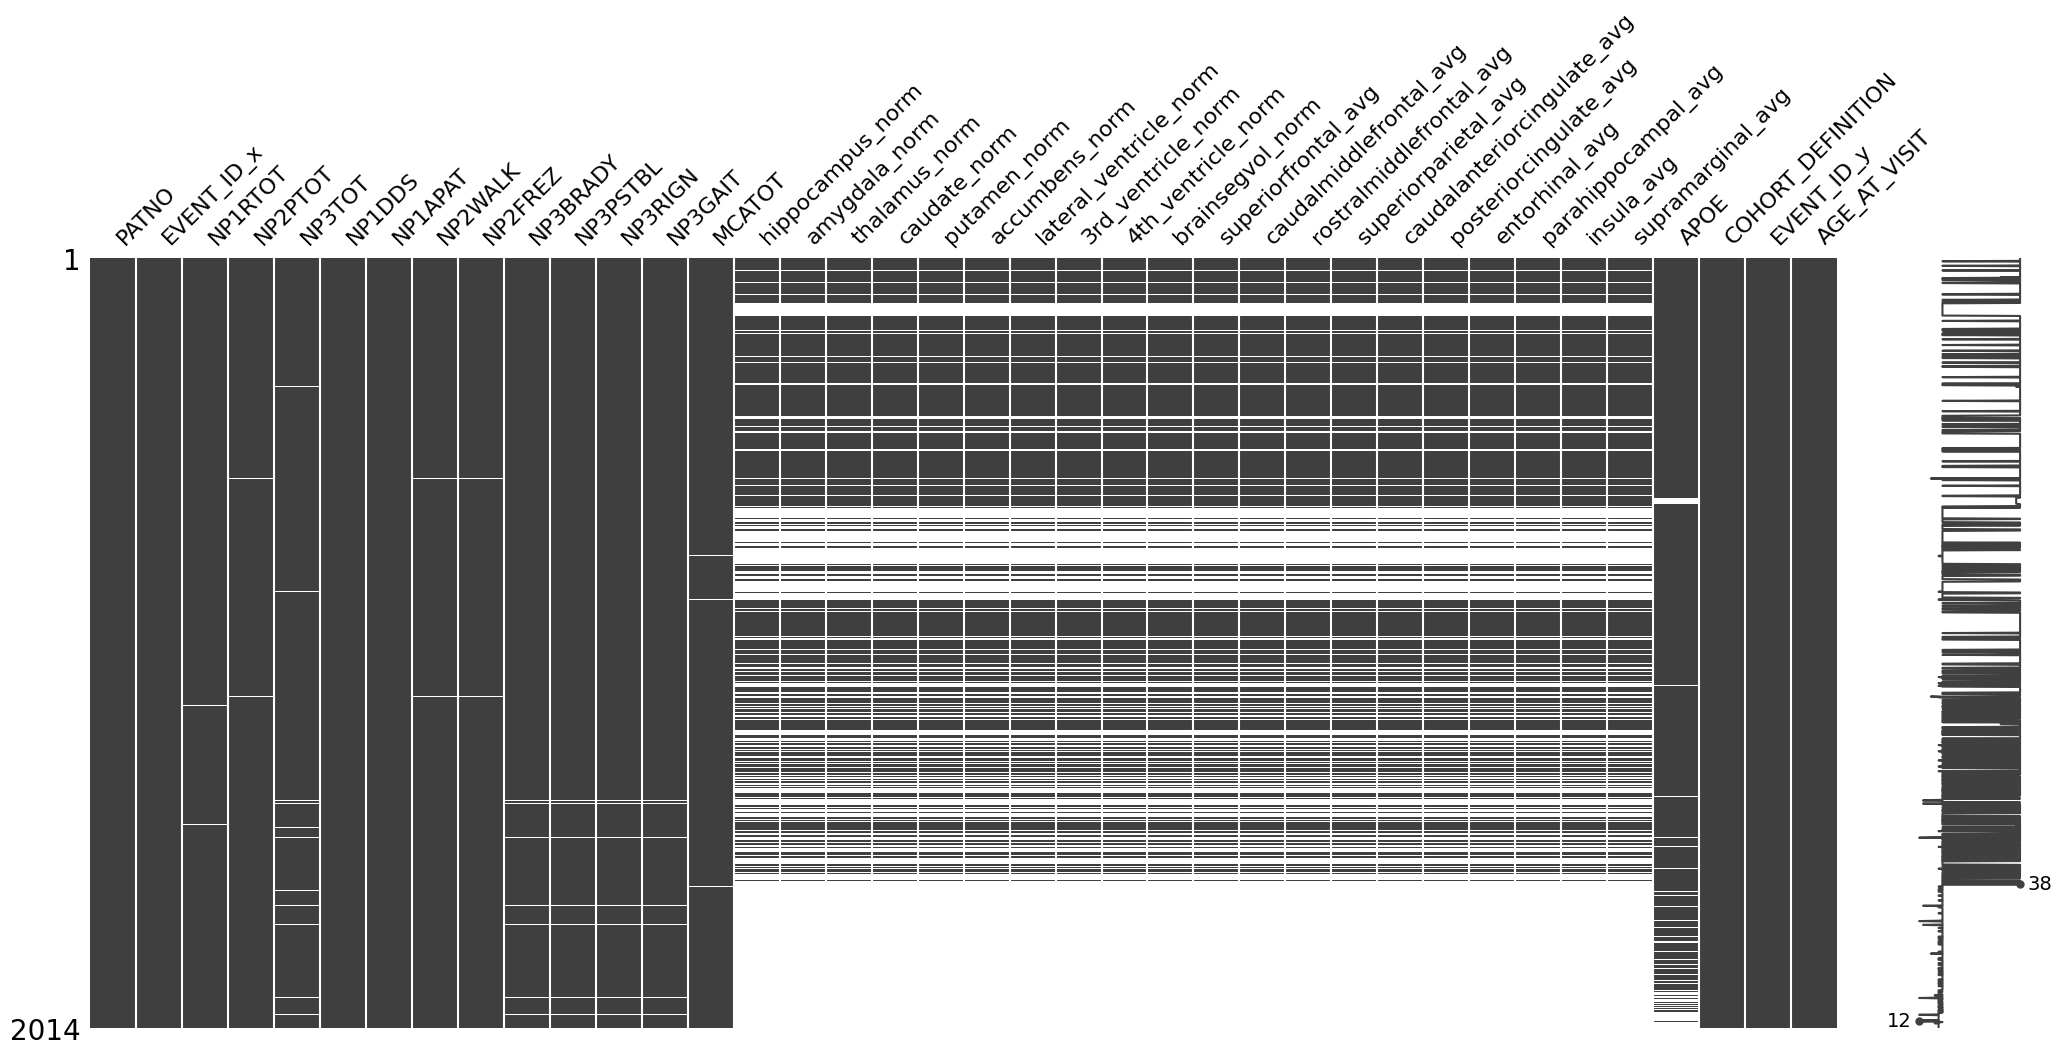

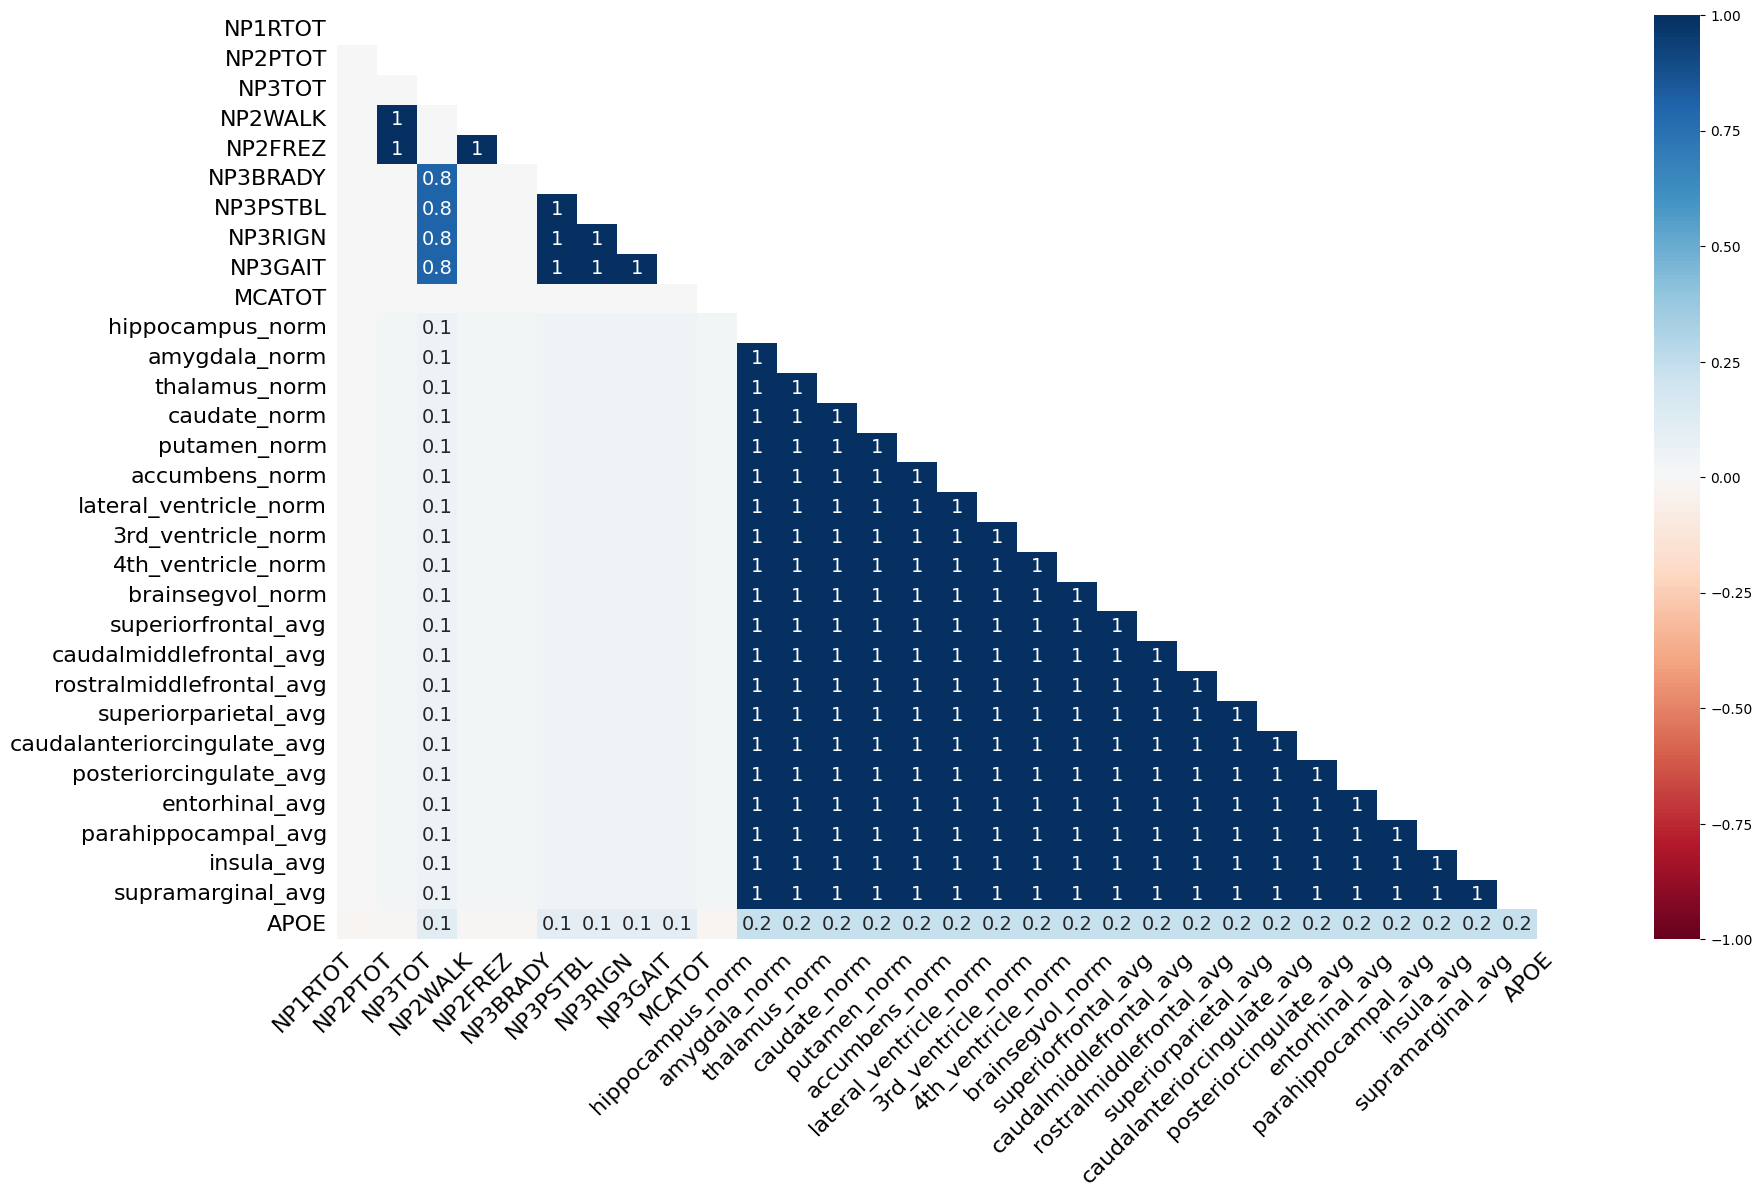

In [35]:
import missingno as msno
import pandas as pd
import matplotlib.pyplot as plt

# Matrix plot
msno.matrix(df)
plt.show()

# Heatmap to see correlation between missing values
msno.heatmap(df)
plt.show()


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def test_mcar_logit(df):
    df = df.copy()
    results = {}

    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue

        # Binary indicator of missingness
        df[f'{col}_missing'] = df[col].isnull().astype(int)

        # Select predictors that are numeric and do not have missing values
        predictors = df.drop(columns=[col, f'{col}_missing'])
        predictors = predictors.select_dtypes(include='number')
        predictors = predictors.dropna(axis=1)

        # Drop rows with any missing predictor
        mask = df[f'{col}_missing'].notna() & predictors.notna().all(axis=1)
        X = predictors[mask]
        y = df.loc[mask, f'{col}_missing']

        if len(np.unique(y)) < 2 or len(y) < 10:
            continue  # Skip if not enough variation or too few samples

        # Train/test split and fit model
        X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        preds = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, preds)
        results[col] = auc

    return results


In [37]:
auc_scores = test_mcar_logit(df)
print(auc_scores)


{'NP1RTOT': np.float64(1.0), 'NP2PTOT': np.float64(0.5387673956262425), 'NP3TOT': np.float64(0.5686077643908969), 'NP2WALK': np.float64(0.9542743538767395), 'NP2FREZ': np.float64(0.9999999999999999), 'NP3BRADY': np.float64(0.999), 'NP3PSTBL': np.float64(1.0), 'NP3RIGN': np.float64(1.0), 'NP3GAIT': np.float64(1.0), 'MCATOT': np.float64(0.5876494023904383), 'hippocampus_norm': np.float64(0.7543462785731234), 'amygdala_norm': np.float64(1.0), 'thalamus_norm': np.float64(1.0), 'caudate_norm': np.float64(1.0), 'putamen_norm': np.float64(1.0), 'accumbens_norm': np.float64(1.0), 'lateral_ventricle_norm': np.float64(1.0), '3rd_ventricle_norm': np.float64(1.0), '4th_ventricle_norm': np.float64(1.0), 'brainsegvol_norm': np.float64(1.0), 'superiorfrontal_avg': np.float64(1.0), 'caudalmiddlefrontal_avg': np.float64(1.0), 'rostralmiddlefrontal_avg': np.float64(1.0), 'superiorparietal_avg': np.float64(1.0), 'caudalanteriorcingulate_avg': np.float64(1.0), 'posteriorcingulate_avg': np.float64(1.0), 'e

**Encode the APOE genotype.**

In [38]:
print(df['APOE'].head(10))

0    E3/E3
1    E3/E3
2    E3/E3
3    E3/E4
4    E2/E3
5    E3/E4
6    E2/E3
7    E3/E3
8    E3/E4
9    E3/E3
Name: APOE, dtype: object


In [39]:
def count_e4_alleles(genotype):
    if pd.isna(genotype):
        return np.nan
    return genotype.count('E4')

df['APOE4'] = df['APOE']
df['APOE4'] = df['APOE4'].apply(count_e4_alleles)


In [40]:
df.head(5)

,PATNO,EVENT_ID_x,NP1RTOT,NP2PTOT,NP3TOT,NP1DDS,NP1APAT,NP2WALK,NP2FREZ,NP3BRADY,...,posteriorcingulate_avg,entorhinal_avg,parahippocampal_avg,insula_avg,supramarginal_avg,APOE,COHORT_DEFINITION,EVENT_ID_y,AGE_AT_VISIT,APOE4
0,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,BL,69.1,0.0
1,3001,BL,0.0,2.0,12.0,0.0,0.0,0.0,0.0,1.0,...,857.5,510.0,767.5,2550.5,4355.0,E3/E3,Parkinson's Disease,BL,65.1,0.0
2,3002,BL,3.0,15.0,17.0,0.0,1.0,1.0,1.0,2.0,...,948.5,417.0,581.0,2083.5,3015.0,E3/E3,Parkinson's Disease,BL,67.6,0.0
3,3003,BL,1.0,6.0,29.0,0.0,0.0,1.0,0.0,2.0,...,804.0,416.0,659.5,2352.5,3477.5,E3/E4,Parkinson's Disease,BL,56.7,1.0
4,3004,BL,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1085.5,509.0,697.0,2404.5,4814.0,E2/E3,Healthy Control,BL,59.4,0.0


In [41]:
df['APOE4'] = df['APOE4'].astype('Int64')

In [42]:
df.head(5)

,PATNO,EVENT_ID_x,NP1RTOT,NP2PTOT,NP3TOT,NP1DDS,NP1APAT,NP2WALK,NP2FREZ,NP3BRADY,...,posteriorcingulate_avg,entorhinal_avg,parahippocampal_avg,insula_avg,supramarginal_avg,APOE,COHORT_DEFINITION,EVENT_ID_y,AGE_AT_VISIT,APOE4
0,3000,BL,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,902.0,513.0,713.0,2522.0,3805.5,E3/E3,Healthy Control,BL,69.1,0
1,3001,BL,0.0,2.0,12.0,0.0,0.0,0.0,0.0,1.0,...,857.5,510.0,767.5,2550.5,4355.0,E3/E3,Parkinson's Disease,BL,65.1,0
2,3002,BL,3.0,15.0,17.0,0.0,1.0,1.0,1.0,2.0,...,948.5,417.0,581.0,2083.5,3015.0,E3/E3,Parkinson's Disease,BL,67.6,0
3,3003,BL,1.0,6.0,29.0,0.0,0.0,1.0,0.0,2.0,...,804.0,416.0,659.5,2352.5,3477.5,E3/E4,Parkinson's Disease,BL,56.7,1
4,3004,BL,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1085.5,509.0,697.0,2404.5,4814.0,E2/E3,Healthy Control,BL,59.4,0


In [43]:
# Drop original APOE genotype column
df.drop(columns=['APOE'], inplace=True)

In [44]:
df['APOE4'].value_counts(dropna=False)


,count
APOE4,
0,1424
1,409
<NA>,149
2,32


In [16]:
df.columns

Index(['PATNO', 'EVENT_ID_x', 'NP1RTOT', 'NP2PTOT', 'NP3TOT', 'NP1DDS',
       'NP1APAT', 'NP2WALK', 'NP2FREZ', 'NP3BRADY', 'NP3PSTBL', 'NP3RIGN',
       'NP3GAIT', 'MCATOT', 'hippocampus_norm', 'amygdala_norm',
       'thalamus_norm', 'caudate_norm', 'putamen_norm', 'accumbens_norm',
       'lateral_ventricle_norm', '3rd_ventricle_norm', '4th_ventricle_norm',
       'brainsegvol_norm', 'superiorfrontal_avg', 'caudalmiddlefrontal_avg',
       'rostralmiddlefrontal_avg', 'superiorparietal_avg',
       'caudalanteriorcingulate_avg', 'posteriorcingulate_avg',
       'entorhinal_avg', 'parahippocampal_avg', 'insula_avg',
       'supramarginal_avg', 'COHORT_DEFINITION', 'EVENT_ID_y', 'AGE_AT_VISIT',
       'APOE4'],
      dtype='object')

**Using MICE simple imputation since missingness in key MRI, Clinical Scores and APOE4 features is still less than 50%**

In [17]:

import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


In [18]:
# Drop identifiers and leakage columns
df = df.drop(columns=['PATNO', 'EVENT_ID_x', 'EVENT_ID_y'])

# Target column
target = 'COHORT_DEFINITION'
X = df.drop(columns=[target])
y = df[target]


In [19]:
# Columns with high missingness (MRI volumes)
mri_cols = [
    'hippocampus_norm', 'amygdala_norm', 'thalamus_norm', 'caudate_norm',
    'putamen_norm', 'accumbens_norm', 'lateral_ventricle_norm',
    '3rd_ventricle_norm', '4th_ventricle_norm', 'brainsegvol_norm',
    'superiorfrontal_avg', 'caudalmiddlefrontal_avg', 'rostralmiddlefrontal_avg',
    'superiorparietal_avg', 'caudalanteriorcingulate_avg',
    'posteriorcingulate_avg', 'entorhinal_avg', 'parahippocampal_avg',
    'insula_avg', 'supramarginal_avg'
]

# Clinical and cognitive scores
clinical_cols = [
    'NP1RTOT', 'NP2PTOT', 'NP3TOT', 'NP1DDS', 'NP1APAT', 'NP2WALK',
    'NP2FREZ', 'NP3BRADY', 'NP3PSTBL', 'NP3RIGN', 'NP3GAIT', 'MCATOT'
]

# APOE4
other_cols = ['AGE_AT_VISIT', 'APOE4']

# All features
all_features = mri_cols + clinical_cols + other_cols


In [45]:
df_clean = df.copy()

# Select columns to impute
features_to_impute = (all_features)
# Copy to isolate features for imputation
df_impute = df_clean[features_to_impute]

In [46]:
# Initialize imputer
imputer = IterativeImputer(random_state=42, max_iter=10, sample_posterior=True)

# Fit and transform the selected features
imputed_array = imputer.fit_transform(df_impute)

# Replace imputed values in the original df
df_imputed = df_clean.copy()
df_imputed[features_to_impute] = imputed_array


In [48]:
# Round and clip APOE4
df_imputed['APOE4'] = df_imputed['APOE4'].round().clip(0, 2).astype(int)


In [50]:
# Save imputed full dataset to CSV
df_imputed.to_csv('ppmi_clean_imputed.csv', index=False)


**Main Output:**

The main output of the script is a new CSV file named ppmi_clean_imputed.csv. This file contains the original data with missing values in the selected MRI volumes, clinical/cognitive scores, age, and APOE4 features replaced by imputed values. The APOE genotype is encoded as the number of E4 alleles (0, 1, or 2).